# MoS2 reconstruction in quantem 

Notebook from Stephanie Ribet and Georgios Varnavides

Data from Y. Zheng et al, Atom-by-atom Imaging of Moiré Phasons using Electron Ptychography, Science (2025).

In [1]:
import numpy as np
import quantem as em
import matplotlib.pyplot as plt

em.core.config.set_device(1)
print(em.__version__)

0.1.8


# load data

In [2]:
# Data can be downloaded from https://doi.org/10.5281/zenodo.18449974
dc = em.io.load("data/mos2_empad_calibrated.zip")
dc

Dataset(shape=(126, 126, 120, 120), dtype=float32, name='4D-STEM dataset')
  sampling: [0.43       0.43       1.64194258 1.64194258]
  units: ['A', 'A', 'mrad', 'mrad']
  signal units: 'arb. units'

In [3]:
# calibrations
PROBE_SEMIANGLE = 25
ENERGY = 80e3

# iterative ptycho

In [4]:
pdset = em.diffractive_imaging.PtychographyDatasetRaster.from_dataset4dstem(
    dc
)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=False,
    plot_com=False,
    probe_energy=ENERGY,
    force_com_rotation=183,
    force_com_transpose = False,
)

Forcing best fit rotation to 183 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/15876 [00:00<?, ?probe position/s]

In [5]:
ptycho_pix = em.diffractive_imaging.PtychoLite.from_dataset(
    dset=pdset,
    num_slices=10,
    obj_type="potential",
    num_probes=6,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    obj_padding_px=(64,64),
    polar_parameters = {
        'C10': 93,
        'C12': 11.988049507141113, 
        'phi12': 0.015169759280979633
    },
    middle_focus=True,
    slice_thicknesses=15,
    device='cpu',
)

In [6]:
constraints = {
    "object":{
        "fix_potential_baseline": True,
        "fix_potential_baseline_factor":0.01,
        "identical_slices":True
        
    },
}

ptycho_pix.reconstruct(
    num_iters=10,  
    batch_size=512,
    constraints=constraints,
    reset = True,
    device=em.core.config.get_device()
)

  0%|          | 0/10 [00:00<?, ?it/s]

# dip

In [ ]:
ptycho_dip = em.diffractive_imaging.PtychoLiteDIP.from_ptycholite(
    ptycholite=ptycho_pix,
    pretrain_iters=500,
    device=em.core.config.get_device(),
    verbose=False,
)

In [9]:
constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -1,
        "identical_slices":True,        
    }
}

ptycho_dip.reconstruct(
    num_iters=10, 
    reset=True, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
)

  0%|          | 0/10 [00:00<?, ?it/s]

In [10]:
constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -1,
        "identical_slices":True,
        "q_lowpass": 1.3,   
    }
}

ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
);

  0%|          | 0/10 [00:00<?, ?it/s]

In [11]:
constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -0.5,
        "identical_slices":True,
        "q_lowpass": 1.4,        
    }
}

ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
);

  0%|          | 0/10 [00:00<?, ?it/s]

In [13]:
constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -0.5,
        "identical_slices":True,
        "q_lowpass": 1.5,        
    }
}

ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
);

  0%|          | 0/10 [00:00<?, ?it/s]

In [14]:
constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -0.5,
        "identical_slices":True,
        "q_lowpass": 1.5,
        
    }
}

ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
);

  0%|          | 0/10 [00:00<?, ?it/s]

In [15]:
constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -0.5,
        "identical_slices":True,
        "q_lowpass": 1.6,
    }
}

ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
);

  0%|          | 0/10 [00:00<?, ?it/s]

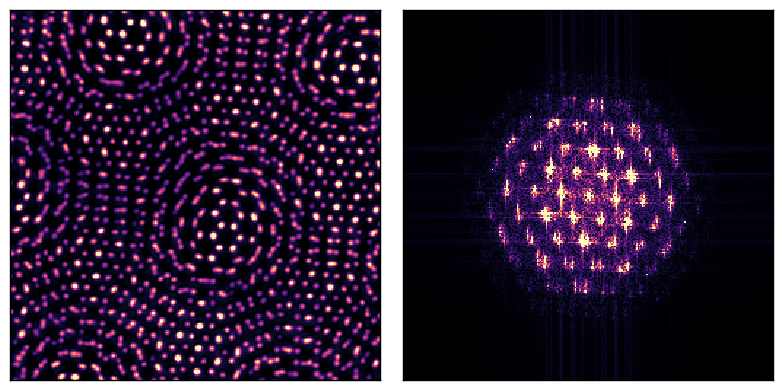

In [17]:
def fft(array):
    return np.abs(np.fft.fftshift(np.fft.fft2(array)))

norm = em.visualization.NormalizationConfig(
    lower_quantile=0.1,
    upper_quantile=0.99
)

em.visualization.show_2d(
    [
        ptycho_dip.obj_cropped.sum(0),
        fft(ptycho_dip.obj_cropped.sum(0))
    ],
    cmap = "magma",
    axsize = (4,4),
    norm = [norm, norm]
);